In [ ]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [34]:
# Nbr of particles
N_list = [2:2:10;]
r = 1
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
Ω_RO = 1e7 # Taken from Barbut arXiv:2412.02541v1

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

In [ ]:
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, N) in enumerate(N_list)
    line = []
    @load "solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

In [ ]:
close("all")
fig, ax = subplots()

for (i, N) in enumerate(N_list)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

In [ ]:
mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(N_list, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(N_list)]))
axes[1].set_xlabel("N")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(N_list, mean_SS./N_list, yerr=std_SS ./ (N_list .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(N_list)])))
axes[2].set_xlabel("N")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Plot the evolutions that didn't work

In [ ]:
close("all")
fig, axes = subplots(1, 2, figsize=(10, 5))
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        @load "r0/r0_N_$(N_list[i])_r_$j.jdl2" r0 L
        if j ∈ nbr_error_t_N[i]
            if line == []
                line, = axes[1].plot(list_t_N[i][j], popup_t_N[i][j], label="N=$(N_list[i])")
            else
                axes[1].plot(list_t_N[i][j], popup_t_N[i][j], color=line.get_color())
            end
            axes[2].scatter(N_list[i], min_r0(r0), color ="r")
        else
            axes[2].scatter(N_list[i], min_r0(r0), color ="b")
        end
    end
end

axes[2].hlines(d0_lb, N_list[1], N_list[end])
axes[1].set_xlabel(L"$\gamma t$")
axes[1].set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
axes[2].set_xlabel(L"N")
axes[2].set_ylabel(L"min(r_0)")
axes[1].legend()
pygui(false); gcf();
# pygui(true); show()

# Timestep 

In [ ]:
close("all")
fig, ax = subplots()
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        T = list_t_N[i][j]
        if j == 1
            line, = ax.plot(T[1:end-1], T[2:end]-T[1:end-1], label=N_list[i])
        else
            ax.plot(T[1:end-1], T[2:end]-T[1:end-1], color=line.get_color())
        end
    end
end


ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\Delta T$")
ax.legend()
pygui(false); gcf();
# pygui(true); show()

# Plot condition evolution

In [ ]:
function stop_condition(popup, T)
    popup_smooth = runmean_window_t(popup, T, window_t)
    boxes = boxmean_window_t(popup_smooth, T[T .> window_var], window_var)
    Delta_boxes = boxes[2:end] - boxes[1:end-1]
    T_boxes = [i*window_var for i in 1:length(Delta_boxes)]
    return Delta_boxes, T_boxes
end

In [ ]:
close("all")
fig, axes = subplots(1, 2, figsize=(15, 5))
max_t = 0

for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            Delta_boxes, T_boxes = stop_condition(popup_t_N[i][j], list_t_N[i][j])

            if line == []
                line, = axes[1].plot(T_boxes,Delta_boxes, label=N_list[i])
            else
                axes[1].plot(T_boxes, Delta_boxes, color=line.get_color())
            end
            if T_boxes[end] > max_t
                max_t = T_boxes[end]
            end
        else
            if list_t_N[i][j][end] > 2*window_var
                Delta_boxes, T_boxes = stop_condition(popup_t_N[i][j], list_t_N[i][j])
                if line == []
                    line, = axes[2].plot(T_boxes,Delta_boxes, label=N_list[i])
                else
                    axes[2].plot(T_boxes, Delta_boxes, color=line.get_color())
                end
            end
        end
    end
end

axes[1].hlines(threshold_box, 0, maximum([maximum([T[end] for T in list_t]) for list_t in list_t_N]), linewidth=0.2), axes[1].hlines(-threshold_box, 0, maximum([maximum([T[end] for T in list_t]) for list_t in list_t_N]), linewidth=0.2)
axes[2].hlines(threshold_box, 0, maximum([maximum([T[end] for T in list_t]) for list_t in list_t_N]), linewidth=0.1)#, axes[2, 2].hlines(-threshold_box_deriv, 0, t_end, linewidth=0.1)


axes[1].set_xlabel(L"$\gamma t$")
axes[1].set_ylabel(L"$\Delta $boxes($\langle  n_{\uparrow} \rangle $)")
axes[1].legend()
axes[1].title.set_text("Working distributions")

axes[2].set_xlabel(L"$\gamma t$")
axes[2].set_ylabel(L"$\Delta $boxes($\langle  n_{\uparrow} \rangle $)")
axes[2].legend()
axes[2].title.set_text("Broken distributions")

pygui(false); gcf();
# pygui(true); show()


# Evolution of individual atoms

In [ ]:
close("all")
fig, ax = subplots()

for (i, N) = enumerate(N_list)
    line = []
    @load "solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    for j = 1:r
        if j ∉ nbr_error_t_N[i]
            # ax.plot(list_t[j], popup_t[j], label="Sum")
            for n in 1:N
                ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$n")
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle n_{\uparrow} \rangle $")
# ax.set_ylim(-0.002, 0.005)
# ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Comparison with spontaneous emission

In [57]:
function deriv_indep_atoms(du, u, p, t)
    γ, Ω = p[1], p[2]
    du[1] = -2γ*u[1] + 1im*Ω*(u[2]-conj(u[2])) # u[1] = ρee, u[2] = ρeg
    du[2] = -γ*u[2] + 1im*Ω*(2*u[1]-1)
end

deriv_indep_atoms (generic function with 1 method)

In [67]:
u0_indep = zeros(ComplexF64, 2)
prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ, Ω_RO])
sol_indep = solve(prob);

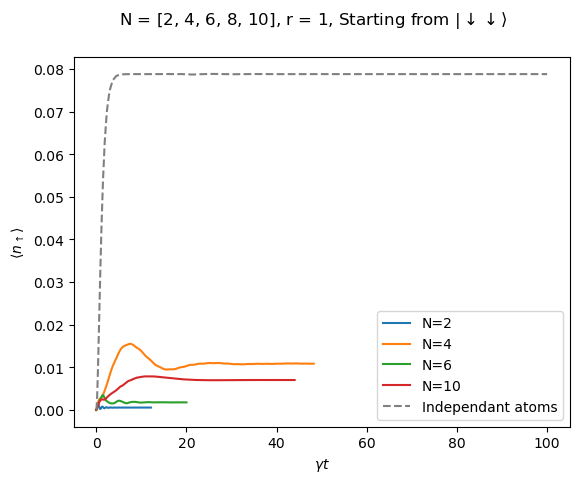

In [68]:
close("all")
fig, ax = subplots()

for (i, N) in enumerate(N_list)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--", color="grey", label="Independant atoms")

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()